## Prompt Chaining Sequential Workflow

Here, we will invoke the LLM 2 times, one after the another, where the output of the first invocation will be the input of the 2nd invocation, then we will get the output.

We will be using an example of blog generation, where 1st node will generate the outline by taking the topic as an input and then 2nd node will generate the blog and give the output.

Lets first import the required modules

In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv
load_dotenv()

model = ChatOpenAI()

here, state will have 3 variables:
1. topic -> which is the input
2. outline -> output of the 1st LLM
3. blog -> output of the 2nd LLM and also the final output

In [3]:
class BlogState(TypedDict):
    topic : str
    outline: str
    blog: str

Now, lets define the nodes

In [8]:
def generate_outline(state: BlogState) -> BlogState:
    
    #Get the topic from the state
    topic = state['topic']

    #Write a prompt
    prompt = f"Generate a detailed outline required to write a blog on the topic : {topic}"

    #Generate outline
    outline = model.invoke(prompt).content 

    #Add this output to the state
    state['outline'] = outline

    return state 

def generate_blog(state:BlogState) -> BlogState:

    #Get both the topic and the output of the 1st node from the LLM
    topic = state['topic']
    outline = state['outline']

    #write the prompt
    prompt = f"Generate a detailed blog on the topic : {topic} using the given blog outline: \n {outline}"

    #Get the blog output from the model
    blog = model.invoke(prompt)

    #Add the final blog output back to the state
    state['blog'] = blog.content

    return state

Now, that we have the nodes, lets define the graph

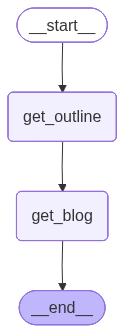

In [9]:
#Lets create a graph with a given state format
graph = StateGraph(BlogState)

#Lets add the nodes
graph.add_node('get_outline', generate_outline)
graph.add_node('get_blog', generate_blog)

#Lets add the edges
graph.add_edge(START, 'get_outline')
graph.add_edge('get_outline', 'get_blog')
graph.add_edge('get_blog', END)

#Lets compile the graph
workflow = graph.compile()

#Lets visualize it also
workflow

Now, lets run the graph


In [10]:
initial_state = {'topic': "One piece anime"}
final_state = workflow.invoke(initial_state)

final_state

{'topic': 'One piece anime',
 'outline': 'I. Introduction\n- Brief overview of "One Piece" anime\n- Explanation of its popularity and enduring success\n\nII. History of One Piece\n- Background information on the manga created by Eiichiro Oda\n- Development of the anime adaptation\n- Success and impact on the anime industry\n\nIII. Plot and Characters\n- Synopsis of the main story arcs\n- Introduction to the main characters and their development throughout the series\n- Analysis of themes explored in the show\n\nIV. Animation and Art Style\n- Discussion of the animation quality and art style of "One Piece"\n- Comparison to other popular anime series\n- Impact of the art style on the overall appeal of the show\n\nV. Cultural Impact\n- Influence of "One Piece" on popular culture in Japan and worldwide\n- Fan community and conventions dedicated to the series\n- Adoption of "One Piece" themes and characters in other media\n\nVI. Controversies and Criticisms\n- Discussion of criticisms the s

First lets see the outline

In [13]:
print(final_state['outline'])

I. Introduction
- Brief overview of "One Piece" anime
- Explanation of its popularity and enduring success

II. History of One Piece
- Background information on the manga created by Eiichiro Oda
- Development of the anime adaptation
- Success and impact on the anime industry

III. Plot and Characters
- Synopsis of the main story arcs
- Introduction to the main characters and their development throughout the series
- Analysis of themes explored in the show

IV. Animation and Art Style
- Discussion of the animation quality and art style of "One Piece"
- Comparison to other popular anime series
- Impact of the art style on the overall appeal of the show

V. Cultural Impact
- Influence of "One Piece" on popular culture in Japan and worldwide
- Fan community and conventions dedicated to the series
- Adoption of "One Piece" themes and characters in other media

VI. Controversies and Criticisms
- Discussion of criticisms the series has faced
- Controversial storylines or characters
- Response

now lets see the blog

In [12]:
print(final_state['blog'])

One Piece Anime: A Legendary Journey

I. Introduction
"One Piece" is one of the most popular and enduring anime series to date, captivating audiences with its epic adventure, lovable characters, and rich world-building. Created by Eiichiro Oda, the manga was first published in 1997 and later adapted into an anime series in 1999. Its popularity has only continued to grow over the years, making it a beloved classic in the anime world.

II. History of One Piece
Eiichiro Oda's "One Piece" manga quickly gained widespread acclaim for its unique story and character designs. The anime adaptation followed soon after and became a massive success in its own right. With its blend of action, comedy, and drama, "One Piece" has had a significant impact on the anime industry, inspiring a new generation of creators and fans.

III. Plot and Characters
"At the beginning of the series, Monkey D. Luffy sets out on a quest to find the legendary One Piece treasure and become the Pirate King. Along the way, h

#### Now  the main difference between the previous langchain workflow and this workflow is that, we wont have access to the intermediate steps output like the blog outline there, but here we will have access to all the outputs at all the stages of the workflow.